In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

#Seaborn
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="dark")

#MPL 
import matplotlib as mpl
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as colors

In [5]:
### Read in the Arene/Aryne SMILES.csv dataset ###

#script is located in cwd
histo_path = Path.cwd()

#mod8 path is one above
mod8_path = histo_path.parent #get the path above this current dir

#tld is one above mod8
project_dir = mod8_path.parent

#data is located in the mod7 dir
data_path = project_dir / "Module7_Extract_DFT_Molecular_Descriptors" / "Aryne_Calculated_Molecular_Descriptors.csv"
incoming_data = pd.read_csv(data_path)
incoming_data.head()

,arene_ID,arene_smiles,arene_energy,aryne_ID,aryne_smiles,aryne_energy,dehydrogenation_energy,Sz_Aryne_Ring,RingSys_Type,Aryne_Aindx_1,...,Max_angle_dev,Sum_abs_dev,Aryne_DiH_Ang,eHOMO(eV),eLUMO(eV),H_L_Gap(eV),Hirsh_chgs_Aindx_1,Hirsh_chgs_Aindx_2,Sum_Abs_Hirsh_aryne,Abs_Dif_Bnd_Angl
0,arene_1,O=c1nc2ccsc2cs1,-1156.0883,aryne_1,O=c1nc2c#csc2cs1,-1154.7269,124.0423,5,multi,4,...,17.4185,20.9698,0.091,-8.2033,-3.1162,5.0871,0.0001,-0.0688,0.0689,13.8672
1,arene_2,c1csn2nn[nH]cc-2o1,-846.4294,aryne_2,c1oc2c[nH]nnn-2sc#1,-845.1003,103.7738,6,multi,9,...,28.1870,32.3229,9.361,-7.5885,-1.8409,5.7476,-0.1534,0.0712,0.2246,32.3229
2,arene_3,O=c1cnc2occsc=2c1=O,-946.3140,aryne_3,O=c1cnc2oc#csc=2c1=O,-944.9744,110.3626,6,multi,6,...,27.9700,28.5260,0.049,-7.6077,-3.6957,3.9120,0.0756,-0.1217,0.1973,27.4140
3,arene_4,O=c1cnc2sc(=O)ccc2s1,-1269.2819,aryne_4,O=c1c#cc2sc(=O)cnc2s1,-1267.9693,93.4199,6,multi,2,...,16.0394,29.2699,0.582,-8.2904,-2.7467,5.5437,-0.0285,-0.0286,0.0571,2.8089
4,arene_5,O=c1ccn2sccsn2[nH]1,-1228.5052,aryne_5,O=c1c#cn2sccsn2[nH]1,-1227.1702,107.4761,6,multi,2,...,11.5546,15.8775,28.895,-7.5024,-1.8204,5.6820,-0.1116,0.0126,0.1242,15.8775


8116


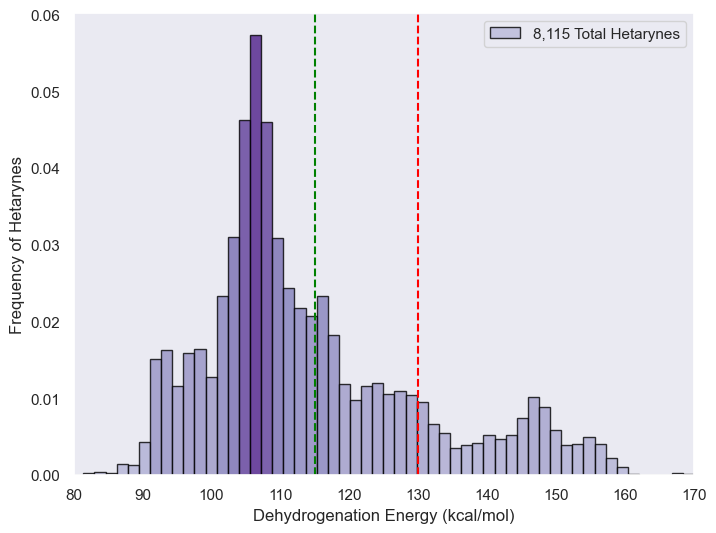

In [7]:
#6-membered dehydrog. energies
dehyd_data = incoming_data["dehydrogenation_energy"]
print(len(dehyd_data))

fig, ax = plt.subplots(figsize=(8,6))

#unified colormap
my_pur = plt.cm.Purples(np.linspace(0.35,0.9,100))
my_pur = ListedColormap(my_pur[8:,:-1])

#unified (5- and 6-membered) hetarynes
m, bins, patches = ax.hist(dehyd_data, bins=80, density=True, edgecolor='black', label='8,115 Total Hetarynes', alpha=0.8)
# To normalize your values
bol = (m-m.min())/(m.max()-m.min()) #contains colormap values 
for c, p in zip(bol, patches):
    plt.setp(p, 'facecolor', my_pur(c))

plt.xlim(80,170)
plt.axvline(x=115, color='green', linestyle='--')
plt.axvline(x=130, color='red', linestyle='--')
ax.set(xlabel='Dehydrogenation Energy (kcal/mol)')
ax.set(ylabel='Frequency of Hetarynes')
ax.legend()

# #save the figure, locally.
plt.savefig('dehydrogenation_energy_histogram_unified.png', bbox_inches="tight", transparent=True)